# Nodata Remapping in Reprojection: the 255 -> 254 bug

Reprojecting a `uint8` categorical raster whose `nodata` is 255 used to return that nodata as **254** - a
perfectly ordinary class label as far as everything downstream is concerned. This notebook reproduces the
mechanism from scratch, shows exactly which rasters it can bite, and shows why `dem_stitcher < 3.0.0`
appeared immune.

**How it surfaced.** `distmetrics` merges OPERA DIST-S1 disturbance tiles (`uint8`, `nodata=255`) that
arrive in different UTM zones. After upgrading to `dem_stitcher >= 3.0.0` its categorical merge regression
test failed: 21.7% of the merged pixels differed from the stored expectation, and the output - which should
only ever contain the labels `{0, 1}` and nodata `255` - came back containing dozens of invented classes
(16-70, 167-213, 254).

**The chain, in one breath.** `reproject_arr_to_match_profile` passed `dst_nodata` to
`rasterio.warp.reproject` but never `src_nodata`, so gdal saw a source with *no* nodata; gdal guarantees
that valid output data never collides with the output nodata, so it nudged every genuine 255 to 254; the
nodata region became data; and the downstream merge then bilinearly blended that 254 against the real class
labels.

Fixed in `dem_stitcher 3.1.2`: `src_nodata` now defaults to `src_profile['nodata']`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from affine import Affine
from rasterio.crs import CRS
from rasterio.warp import Resampling, reproject, transform_bounds

from dem_stitcher.merge import _aligned_pixel_offsets, merge_arrays_with_geometadata
from dem_stitcher.rio_tools import reproject_arr_to_match_profile, reproject_profile_to_new_crs

FIGSIZE = (13, 4)
CMAP = 'viridis'
UTM_16N, UTM_17N = CRS.from_epsg(32616), CRS.from_epsg(32617)

print('gdal', rasterio.__gdal_version__, '| rasterio', rasterio.__version__)

gdal 3.12.4 | rasterio 1.5.0


## 1. The mechanism on a 4 x 4 array

A tiny categorical raster in UTM 17N: a 2 x 2 block of class `1`, everything else nodata `255`. We reproject
it into UTM 16N three ways.

In [2]:
p_src = {
    'driver': 'GTiff',
    'dtype': 'uint8',
    'nodata': 255,
    'width': 4,
    'height': 4,
    'count': 1,
    'crs': UTM_17N,
    'transform': Affine(30.0, 0.0, 500_000.0, 0.0, -30.0, 3_600_000.0),
}

X_src = np.full((4, 4), 255, dtype=np.uint8)
X_src[1:3, 1:3] = 1
p_ref = reproject_profile_to_new_crs(p_src, UTM_16N)

X_src

array([[255, 255, 255, 255],
       [255,   1,   1, 255],
       [255,   1,   1, 255],
       [255, 255, 255, 255]], dtype=uint8)

In [3]:
def warp(dst_dtype, src_nodata):
    dst = np.zeros((p_ref['height'], p_ref['width']), dtype=dst_dtype)
    reproject(
        X_src,
        dst,
        src_transform=p_src['transform'],
        src_crs=p_src['crs'],
        src_nodata=src_nodata,
        dst_transform=p_ref['transform'],
        dst_crs=p_ref['crs'],
        dst_nodata=p_src['nodata'],
        resampling=Resampling.nearest,
    )
    return dst


X_broken = warp('uint8', None)
X_legacy = warp('float64', None).astype('uint8')
X_fixed = warp('uint8', 255)

X_broken

array([[254, 254, 254, 254],
       [254,   1,   1, 254],
       [254,   1,   1, 254],
       [254, 254, 254, 254]], dtype=uint8)

`X_broken` is what `dem_stitcher 3.0.0 - 3.1.1` produced: the nodata ring came back as **254**. Note gdal is
not silent about it - it logs

```
CPLE_AppDefined: Value 255 in the source dataset has been changed to 254 in the destination dataset
to avoid being treated as NoData. To avoid this, select a different NoData value for the destination dataset.
```

which is easy to miss in a test log, and says nothing about *why* 255 was considered ordinary data.

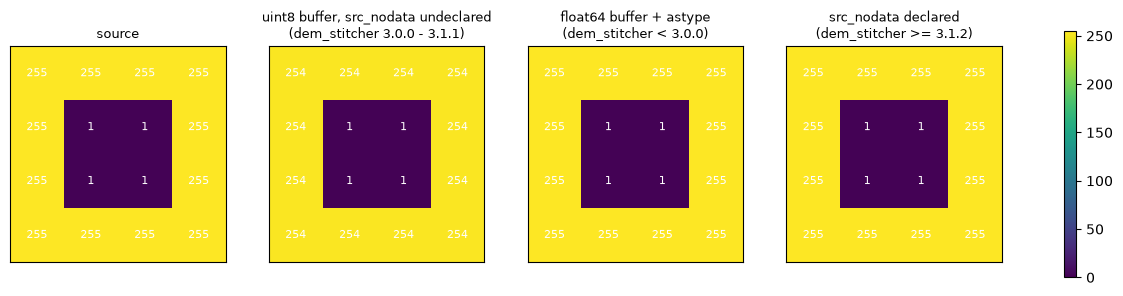

In [4]:
PANELS = [
    ('source', X_src),
    ('uint8 buffer, src_nodata undeclared\n(dem_stitcher 3.0.0 - 3.1.1)', X_broken),
    ('float64 buffer + astype\n(dem_stitcher < 3.0.0)', X_legacy),
    ('src_nodata declared\n(dem_stitcher >= 3.1.2)', X_fixed),
]

fig, axes = plt.subplots(1, len(PANELS), figsize=(16, 4))
for ax, (title, X) in zip(axes, PANELS):
    im = ax.imshow(X, cmap=CMAP, vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    [ax.text(j, i, X[i, j], ha='center', va='center', color='white', fontsize=8)
     for i in range(X.shape[0]) for j in range(X.shape[1])]
    ax.set_xticks([]), ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## 2. So when *does* gdal nudge the value?

The rule is not about categorical data, or `uint8`, or even integers. gdal enforces one invariant: **a pixel
that carries valid source data must never come back equal to the destination nodata**, because a reader
would then mistake it for nodata. When a warped value lands exactly on `dst_nodata`, gdal shifts it by one
representable step. The implementation is
[`AvoidNoData()` in `alg/gdalwarpkernel.cpp`](https://github.com/OSGeo/gdal/blob/v3.12.4/alg/gdalwarpkernel.cpp#L1498):

```cpp
template <class T> inline void AvoidNoData(T *pDst, GPtrDiff_t iDstOffset)
{
    if constexpr (cpl::NumericLimits<T>::is_integer)
    {
        if (pDst[iDstOffset] == static_cast<T>(cpl::NumericLimits<T>::lowest()))
            pDst[iDstOffset] = static_cast<T>(cpl::NumericLimits<T>::lowest() + 1);
        else
            pDst[iDstOffset]--;                                  // 255 -> 254
    }
    else
    {
        ...
        pDst[iDstOffset] = nextafter(pDst[iDstOffset], cpl::NumericLimits<T>::max());  // one ulp
    }
}
```

Integers decrement by one whole unit (or increment off the type minimum); floats move one ulp toward the
type maximum - both directions visible in the sweep below.

The sweep below varies the source dtype, the nodata value, and the dtype of the destination buffer.

In [5]:
def nudge_trial(src_dtype, nodata, dst_dtype):
    profile = {**p_src, 'dtype': src_dtype, 'nodata': nodata}
    X = np.full((4, 4), nodata, dtype=src_dtype)
    X[1:3, 1:3] = 1
    profile_ref = reproject_profile_to_new_crs(profile, UTM_16N)
    dst = np.zeros((profile_ref['height'], profile_ref['width']), dtype=dst_dtype)
    reproject(
        X,
        dst,
        src_transform=profile['transform'],
        src_crs=profile['crs'],
        dst_transform=profile_ref['transform'],
        dst_crs=profile_ref['crs'],
        dst_nodata=nodata,
        resampling=Resampling.nearest,
    )
    corner = dst[0, 0]
    intact = np.isnan(corner) if np.isnan(np.float64(nodata)) else corner == nodata
    return {
        'src dtype': src_dtype,
        'nodata': nodata,
        'dst buffer': np.dtype(dst_dtype).name,
        'nodata pixel returns': repr(corner),
        'survives': intact,
    }


TRIALS = [
    ('uint8', 255, 'uint8'),
    ('uint8', 1, 'uint8'),
    ('uint8', 0, 'uint8'),
    ('int16', -32768, 'int16'),
    ('uint16', 65535, 'uint16'),
    ('float32', -9999.0, 'float32'),
    ('float32', 0.0, 'float32'),
    ('float32', np.nan, 'float32'),
    ('uint8', 255, 'float32'),
    ('uint8', 255, 'float64'),
    ('float32', -9999.0, 'float64'),
]

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    table = pd.DataFrame([nudge_trial(*trial) for trial in TRIALS])
table

,src dtype,nodata,dst buffer,nodata pixel returns,survives
0,uint8,255.0,uint8,np.uint8(254),False
1,uint8,1.0,uint8,np.uint8(0),False
2,uint8,0.0,uint8,np.uint8(0),True
3,int16,-32768.0,int16,np.int16(-32767),False
4,uint16,65535.0,uint16,np.uint16(65534),False
5,float32,-9999.0,float32,np.float32(-9998.999),False
6,float32,0.0,float32,np.float32(0.0),True
7,float32,NaN,float32,np.float32(nan),True
8,uint8,255.0,float32,np.float32(255.00002),False
9,uint8,255.0,float64,np.float64(255.00000000000003),False


Reading the table:

* **Every dtype is affected, integer or float.** A float DEM with `nodata=-9999.0` comes back as
  `-9998.999999999998`. My first read of this bug was "gdal only does this for integer destinations" - the
  sweep says otherwise.
* **`nan` is immune.** `nan != nan`, so no value ever *collides* with a `nan` nodata and there is nothing to
  nudge. This is why `dem_stitcher`'s own DEM paths never hit this: glo_30 / srtm / nasadem all carry `nan`.
* **`0` is exempt** - but not because gdal spares it. rasterio drops it before gdal ever sees it:
  [`_warp.pyx` line 465](https://github.com/rasterio/rasterio/blob/1.5.0/rasterio/_warp.pyx#L465) reads
  `dst_nodata = dst_nodata or src_nodata`, so a falsy `0` falls through to the default and gdal is never
  told there is an output nodata to collide with. Section 6 shows this directly. Had gdal seen it, a
  `uint8` `0` sits at the type minimum and would shift *up* to `1` - which is precisely the `0 -> 1`
  corruption reported in [gdal#11711](https://github.com/OSGeo/gdal/issues/11711). `nodata=1` shifts down
  to `0`: away from the minimum the nudge decrements.
* **The destination buffer dtype decides how big the nudge is**, not whether it happens: one whole unit in
  an integer buffer (`255 -> 254`), one ulp in a float buffer (`255 -> 255.00000000000003`).

That last row is the whole story of the regression.

## 3. Why this never bit anyone before - two independent layers of luck

The immunity of older setups turns out to have *two* separate causes, and pinning them down required
reading gdal's history, not just its current source.

**Layer 1: gdal did not police unmasked warps until 3.11.** The collision-avoidance itself is old - it has
guarded the *masked* pixel paths (`GWKSetPixelValue*`) since at least gdal 2.0 (2015). But with
`src_nodata` undeclared there is no source mask, and the warper takes its `NoMasksOrDstDensityOnly` fast
paths - and through gdal 3.9.0 **none** of those fast paths checked for nodata collisions at all (verified
by grepping every `GWK*NoMasks*` function body in the 3.9.0 source: zero hits on `padfDstNoDataReal`). An
unmasked reproject simply wrote 255 as 255. Around 3.10 the replacement started leaking into more paths
inconsistently ([gdal#11711](https://github.com/OSGeo/gdal/issues/11711) reports `0 -> 1` appearing on a
3.9.1 to 3.10.1 upgrade), and gdal 3.11.0 unified it: every path now calls `AvoidNoData()`
([PR #11713](https://github.com/OSGeo/gdal/pull/11713), commit
[`17a737fb`](https://github.com/OSGeo/gdal/commit/17a737fbd7), 2025-01-24) and the runtime warning was
added the same day (commit [`2b0b1c5b`](https://github.com/OSGeo/gdal/commit/2b0b1c5bc9)).

**Layer 2: the float64 buffer truncated the nudge.** Before 3.0.0, `reproject_arr_to_match_profile`
allocated a `float64` destination and cast afterwards:

```python
dst_array = np.zeros((count, height, width))        # float64
reproject(...)
return dst_array.astype(src_dtype), reproject_profile
```

3.0.0 allocated the buffer in the source dtype and dropped the cast (a sensible change on its own - it
halves peak memory and stops silently rounding):

```python
dst_array = np.zeros(dst_shape, dtype=src_dtype)    # uint8
reproject(...)
return dst_array, reproject_profile
```

Under gdal >= 3.11 the nudge happens in **both** versions - but in a `float64` working buffer it is one ulp
(`255 -> 255.00000000000003`) and the `astype('uint8')` truncated it back to 255.

The corruption therefore requires **both** upgrades to land:

| | gdal <= 3.9 | gdal >= 3.11 |
|---|---|---|
| **dem_stitcher < 3.0.0** (float64 + astype) | no nudge at all | nudged one ulp, truncated away |
| **dem_stitcher >= 3.0.0** (source-dtype buffer) | no nudge at all | **255 -> 254, corrupted** |

gdal 3.11.0 shipped May 2025 and dem_stitcher 3.0.0 in August 2026, which is why a code path unchanged in
spirit since 2022 failed only now, and why bisecting either package alone gives a confusing answer - the
line that changed in 3.0.0 is not the line that was wrong.

The 3.10.x column boundary is ragged, per "inconsistent": the repo's former py310 CI environment resolved
libgdal 3.10.3, where the *nearest* fast path demonstrably does not nudge - the artifact-demonstrating
assertions in `tests/test_rio_tools.py` failed there - while
[gdal#11711](https://github.com/OSGeo/gdal/issues/11711) shows the *bilinear* path already nudging in
3.10.1. Only from 3.11.0 is the behavior uniform, which is why the pixi environments now pin
`gdal`/`libgdal-core >= 3.11` (and why 3.1.2 drops python 3.10, whose conda-forge geo stack cannot reach
libgdal 3.11).

In [6]:
nudged_float = warp('float64', None)[0, 0]
print('float64 buffer holds :', repr(nudged_float))
print('after astype(uint8)  :', np.array([nudged_float]).astype('uint8')[0], '  <- the corruption is truncated away')
print('uint8 buffer holds   :', warp('uint8', None)[0, 0], '  <- nothing left to undo it')

float64 buffer holds : np.float64(255.00000000000003)
after astype(uint8)  : 255   <- the corruption is truncated away
uint8 buffer holds   : 254   <- nothing left to undo it


So under the gdal in this environment (3.12.4) the old code was never *correct*, only lucky: the nudge
landed in the 15th decimal place of a float64 and the cast truncated it out of existence - and under older
gdal there was nothing to truncate because unmasked warps were never policed. Two accidents, stacked.

## 4. What it does to a categorical merge

The remap is only the first domino. Two synthetic disturbance tiles in adjacent UTM zones, partially
overlapping, labels `4` and `1`, nodata `255` - the shape of the real `distmetrics` inputs.

In [7]:
RES = 30.0
BOUNDS_B = (500_000.0, 3_600_000.0, 530_000.0, 3_630_000.0)


def build_tile(crs, bounds, label):
    west, south, east, north = bounds
    width, height = int((east - west) / RES), int((north - south) / RES)
    profile = {
        'driver': 'GTiff',
        'dtype': 'uint8',
        'nodata': 255,
        'count': 1,
        'width': width,
        'height': height,
        'crs': crs,
        'transform': Affine(RES, 0.0, west, 0.0, -RES, north),
    }
    X = np.full((height, width), 255, dtype=np.uint8)
    X[height // 4: 3 * height // 4, width // 4: 3 * width // 4] = label
    return X, profile


bounds_a = transform_bounds(UTM_16N, UTM_17N, BOUNDS_B[0] + 15_000.0, BOUNDS_B[1], BOUNDS_B[2] + 15_000.0, BOUNDS_B[3])
X_b, p_b = build_tile(UTM_16N, BOUNDS_B, 1)
X_a, p_a = build_tile(UTM_17N, bounds_a, 4)

p_a_reprojected = reproject_profile_to_new_crs(p_a, UTM_16N)
print('tile A resolution after reprojection:', p_a_reprojected['transform'].a)
print('tile B resolution                   :', p_b['transform'].a)
print('pixel-aligned for the numpy fast path:', _aligned_pixel_offsets([p_b, p_a_reprojected]))

tile A resolution after reprojection: 29.89553840730182
tile B resolution                   : 30.0
pixel-aligned for the numpy fast path: None


The two grids are not pixel-aligned, so `merge_arrays_with_geometadata` cannot take its numpy fast path and
falls back to `rasterio.merge`, which resamples tile A onto tile B's grid with its default **bilinear**
kernel. Bilinear blending is where a stray 254 stops being one wrong value and becomes a spectrum.

In [8]:
def legacy_reproject(src_array, src_profile, ref_profile, resampling):
    dst = np.zeros((ref_profile['height'], ref_profile['width']), dtype=src_profile['dtype'])
    reproject(
        src_array,
        dst,
        src_transform=src_profile['transform'],
        src_crs=src_profile['crs'],
        dst_transform=ref_profile['transform'],
        dst_crs=ref_profile['crs'],
        dst_nodata=src_profile['nodata'],
        resampling=Resampling[resampling],
    )
    return dst


X_a_legacy = legacy_reproject(X_a, p_a, p_a_reprojected, 'nearest')
X_a_fixed = reproject_arr_to_match_profile(X_a, p_a, p_a_reprojected, resampling='nearest')[0].squeeze()

merged_legacy, _ = merge_arrays_with_geometadata([X_b, X_a_legacy], [p_b, p_a_reprojected], method='min')
merged_fixed, _ = merge_arrays_with_geometadata([X_b, X_a_fixed], [p_b, p_a_reprojected], method='min')

labels_legacy = np.unique(merged_legacy).tolist()
labels_fixed = np.unique(merged_fixed).tolist()
print(f'legacy reprojection -> {len(labels_legacy):3d} distinct values in the merge: {labels_legacy[:12]} ...')
print(f'3.1.2 reprojection  -> {len(labels_fixed):3d} distinct values in the merge: {labels_fixed}')

legacy reprojection -> 129 distinct values in the merge: [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 19] ...
3.1.2 reprojection  ->   3 distinct values in the merge: [1, 4, 255]


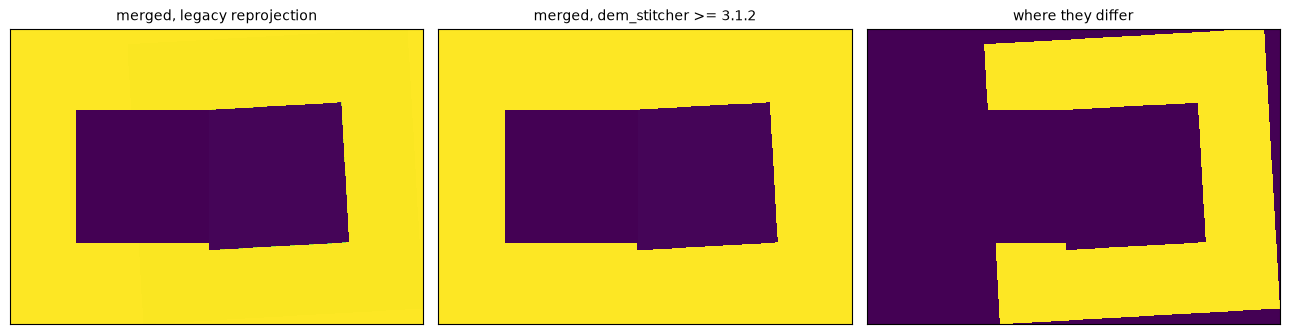

In [9]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)
for ax, (title, X) in zip(
    axes,
    [
        ('merged, legacy reprojection', merged_legacy[0]),
        ('merged, dem_stitcher >= 3.1.2', merged_fixed[0]),
        ('where they differ', (merged_legacy[0] != merged_fixed[0]).astype(np.uint8)),
    ],
):
    ax.imshow(X, cmap=CMAP, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]), ax.set_yticks([])
plt.tight_layout()
plt.show()

Two labels in, more than a hundred out. And note how quietly it fails: the merged array has the right shape,
the right transform, the right crs, the right nodata in its profile, and a plausible-looking picture. Only
the *values* are wrong, and only where the nodata used to be.

There is a second effect worth naming: any downstream mask built from the profile
(`arr == profile['nodata']`) misses the entire 254 region, so the corrupted pixels are never masked, never
dilated away, and are treated as real observations by whatever consumes the merge.

## 5. The fix, and when to reach for `src_nodata`

`dem_stitcher 3.1.2` takes the source nodata from the source profile by default:

```python
src_nodata = _resolve_src_nodata(src_nodata, src_profile)  # None -> src_profile['nodata']
```

Passing `src_nodata` explicitly still works - it overrides the profile and warns, so an override is never
silent. `0` is honored as a value rather than swallowed as an omission (an `or` would have gotten this
wrong, and `0` is a very common nodata).

In [10]:
X_default = reproject_arr_to_match_profile(X_src, p_src, p_ref, resampling='nearest')[0].squeeze()

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    X_override = reproject_arr_to_match_profile(X_src, p_src, p_ref, resampling='nearest', src_nodata=1)[0].squeeze()

print('default (profile nodata masked):', np.unique(X_default).tolist())
print('override src_nodata=1          :', np.unique(X_override).tolist())
print('warning                        :', caught[0].message)

default (profile nodata masked): [1, 255]
override src_nodata=1          : [254, 255]


To reproject a source whose nodata should genuinely *not* be masked, set it on the profile - `None` no
longer means "declare nothing", because that was the bug:

```python
X_r, p_r = reproject_arr_to_match_profile(X, {**profile, 'nodata': None}, p_ref)
```

### Does this bite my raster?

Every one of these has to be true, which is why it stayed hidden for so long:

1. the source profile declares a **finite** nodata (`nan` is immune) that is **not 0**;
2. that value actually occurs in the array;
3. the same value is used as the destination nodata - `dem_stitcher` does this for you, which is what makes
   the collision certain rather than unlucky;
4. the source nodata is not declared to the warper - fixed in 3.1.2;
5. a warp actually happens. An array already in the target crs is passed through untouched, which is why
   only *one* of the two `distmetrics` tiles was corrupted and the bug looked non-deterministic;
6. and, since 3.0.0, nothing casts the nudge away afterwards.

Categorical rasters sit in the sweet spot: integer dtype, a finite sentinel nodata like 255 or 0, and no
tolerance for a value being off by one, because "off by one" is a different class, not a rounding error.

## 6. A footnote: `dst_nodata=0` is silently ignored

While checking whether an unequal `src_nodata`/`dst_nodata` pair is dangerous, a separate quirk turned up.
An unequal *declared* pair is handled correctly - the source nodata is masked and the destination is filled
with `dst_nodata`. But ask for an output nodata of `0` and you do not get it: rasterio's
[`_warp.pyx` line 465](https://github.com/rasterio/rasterio/blob/1.5.0/rasterio/_warp.pyx#L465)
(`dst_nodata = dst_nodata or src_nodata`) drops the falsy `0` and the fill falls back to `src_nodata` -
[`rasterio.warp.reproject`'s docs](https://rasterio.readthedocs.io/en/stable/api/rasterio.warp.html) even
say so, deadpan: `dst_nodata` defaults to "the value of src_nodata, or 0 (GDAL default)".

In [11]:
p_dem = {**p_src, 'dtype': 'float32', 'nodata': -9999.0}
X_dem = np.full((4, 4), -9999.0, dtype=np.float32)
X_dem[1:3, 1:3] = 7.0

for dst_nodata in [-32768.0, 0.0]:
    dst = np.full((p_ref['height'], p_ref['width']), 12345.0, dtype='float32')
    reproject(
        X_dem,
        dst,
        src_transform=p_dem['transform'],
        src_crs=p_dem['crs'],
        src_nodata=p_dem['nodata'],
        dst_transform=p_ref['transform'],
        dst_crs=p_ref['crs'],
        dst_nodata=dst_nodata,
        resampling=Resampling.nearest,
    )
    print(f'src_nodata=-9999.0, dst_nodata={dst_nodata!r:9s} -> nodata region holds {dst[0, 0]!r}')

src_nodata=-9999.0, dst_nodata=-32768.0  -> nodata region holds np.float32(-32768.0)
src_nodata=-9999.0, dst_nodata=0.0       -> nodata region holds np.float32(-9999.0)


`-32768.0` is honored; `0.0` is not, and the nodata region comes back holding the *source* nodata instead.
`dem_stitcher` has its own version of the same falsy-zero trap one layer up - `nodata = nodata or
src_profile['nodata']` means passing `nodata=0` silently keeps the profile's value - so a caller asking for
an output nodata of `0` is refused twice, quietly, and the returned profile agrees with the array either
way. No corruption here, just a request that evaporates; worth knowing before trusting `nodata=0`.

## 7. Sources

The nudge itself is undocumented in gdal's user docs - the paper trail is the warning string, the issue
tracker, and the source:

* [`AvoidNoData()` in `alg/gdalwarpkernel.cpp` @ v3.12.4](https://github.com/OSGeo/gdal/blob/v3.12.4/alg/gdalwarpkernel.cpp#L1498) - the mechanism: integers decrement, floats move one ulp toward the type max.
* [gdal#11711](https://github.com/OSGeo/gdal/issues/11711) - the motivating report: `dstNodata=0` + bilinear + `uint8` turned an all-zeros array into all ones after a 3.9.1 -> 3.10.1 upgrade.
* [gdal PR #11713](https://github.com/OSGeo/gdal/pull/11713) - "fix inconsistent replacement of valid value that collides with the dstnodata value" (commit [`17a737fb`](https://github.com/OSGeo/gdal/commit/17a737fbd7), 2025-01-24, gdal 3.11.0): applies `AvoidNoData()` on every warp path, including the previously unpoliced `NoMasks` fast paths.
* [gdal commit `2b0b1c5b`](https://github.com/OSGeo/gdal/commit/2b0b1c5bc9) - adds the `CPLE_AppDefined ... has been changed to ... to avoid being treated as NoData` runtime warning (same day, gdal 3.11.0).
* [gdal#13677](https://github.com/OSGeo/gdal/issues/13677) - open report of the same avoidance misfiring on multi-band `UNIFIED_SRC_NODATA` warps; this corner of gdal is still moving.
* [`gdalwarp` docs](https://gdal.org/en/stable/programs/gdalwarp.html) - `-srcnodata` / `-dstnodata` / `UNIFIED_SRC_NODATA` semantics: "masked values will not be used in interpolation".
* [rasterio `_warp.pyx` line 465 @ 1.5.0](https://github.com/rasterio/rasterio/blob/1.5.0/rasterio/_warp.pyx#L465) and [`rasterio.warp` API docs](https://rasterio.readthedocs.io/en/stable/api/rasterio.warp.html) - the falsy-zero `dst_nodata` fallback of section 6.
* [dem-stitcher#157](https://github.com/ACCESS-Cloud-Based-InSAR/dem-stitcher/issues/157) - the earlier in-memory-profile bug, for the 3.0.0 context around the buffer-dtype change.

Versions used throughout this notebook: the pinned pixi environment (gdal 3.12.4, rasterio 1.5.0,
dem_stitcher >= 3.1.2). Sections 1-2 and 4-6 are pure `rasterio.warp.reproject` behavior and reproduce
with any gdal >= 3.11; under gdal <= 3.9 the unmasked warps in sections 1-4 return unnudged values
instead, per section 3.